In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")

# 1. Carrega os dados de treino e teste
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

print(f"Shape Treino: {train_df.shape}")
print(f"Shape Teste:  {test_df.shape}\n")

# 2. Exibe as 21 colunas e tipos
print("--- Visão Geral das Colunas ---")
resumo = pd.DataFrame({
    'Tipo': train_df.dtypes,
    'Nulos': train_df.isnull().sum(),
    '% Nulos': (train_df.isnull().sum() / len(train_df)) * 100,
    'Valores Únicos': train_df.nunique()
})
display(resumo)

Shape Treino: (182125, 10)
Shape Teste:  (45531, 9)

--- Visão Geral das Colunas ---


,Tipo,Nulos,% Nulos,Valores Únicos
transaction_id,int64,0,0.0,182125
user_id,int64,0,0.0,5000
timestamp,int64,0,0.0,171502
amount,float64,0,0.0,182125
merchant_category,int64,0,0.0,20
country,int64,0,0.0,30
device_id,int64,0,0.0,8743
channel,int64,0,0.0,2
hours_since_prev_txn,float64,0,0.0,97881
label,int64,0,0.0,2


Total de Transações: 182,125
Transações Legítimas (0): 179,135 (98.36%)
Transações Fraudulentas (1): 2,990 (1.64%)
Razão de Desbalanceamento: 1 fraude para cada 60 legítimas.


/tmp/ipykernel_27601/3950655709.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette=['#1f77b4', '#d62728'], ax=ax)


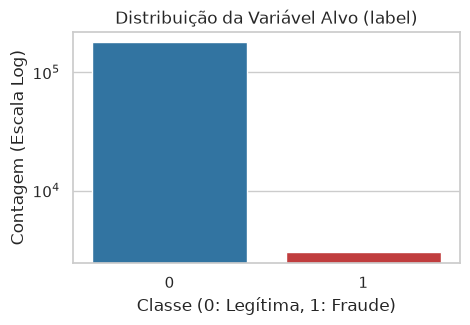

In [3]:
# 1. Taxa de Desbalanceamento do Alvo (label)
fraud_counts = train_df['label'].value_counts()
fraud_pct = train_df['label'].value_counts(normalize=True) * 100

print(f"Total de Transações: {len(train_df):,}")
print(f"Transações Legítimas (0): {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)")
print(f"Transações Fraudulentas (1): {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)")
print(f"Razão de Desbalanceamento: 1 fraude para cada {int(round(fraud_counts[0]/fraud_counts[1]))} legítimas.")

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette=['#1f77b4', '#d62728'], ax=ax)
ax.set_title("Distribuição da Variável Alvo (label)")
ax.set_xlabel("Classe (0: Legítima, 1: Fraude)")
ax.set_ylabel("Contagem (Escala Log)")
ax.set_yscale('log')
plt.show()

/tmp/ipykernel_27601/54684575.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='label', y='amount', ax=axes[0], palette=['#1f77b4', '#d62728'])
/tmp/ipykernel_27601/54684575.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='label', y='hours_since_prev_txn', ax=axes[1], palette=['#1f77b4', '#d62728'])


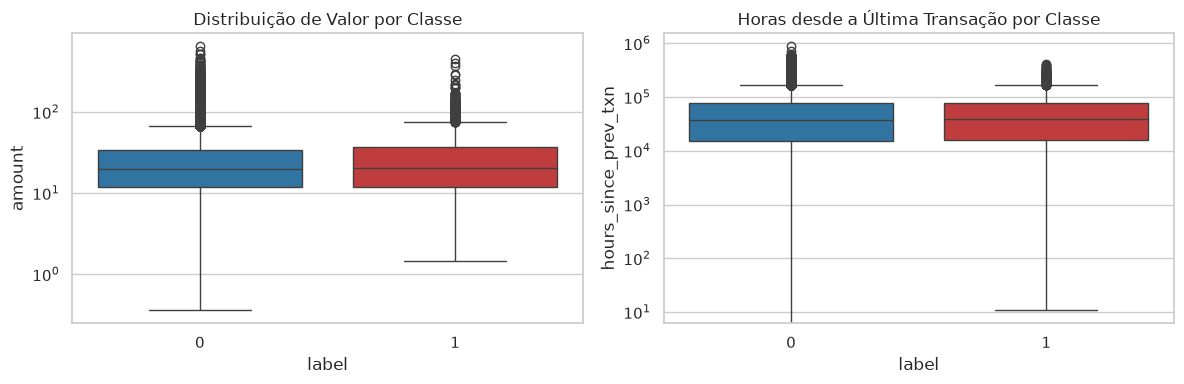

In [4]:
# 2. Comparativo de Comportamento: Fraude vs. Legítima
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Comparação do Valor da Transação (Amount)
sns.boxplot(data=train_df, x='label', y='amount', ax=axes[0], palette=['#1f77b4', '#d62728'])
axes[0].set_title("Distribuição de Valor por Classe")
axes[0].set_yscale('log')

# Comparação do Tempo desde a última transação (hours_since_prev_txn)
sns.boxplot(data=train_df, x='label', y='hours_since_prev_txn', ax=axes[1], palette=['#1f77b4', '#d62728'])
axes[1].set_title("Horas desde a Última Transação por Classe")
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [5]:
# 3. Estatísticas por Usuário
user_stats = train_df.groupby('user_id').agg(
    total_tx=('transaction_id', 'count'),
    mean_amount=('amount', 'mean'),
    std_amount=('amount', 'std'),
    fraud_tx=('label', 'sum')
)
user_stats['has_fraud'] = (user_stats['fraud_tx'] > 0).astype(int)

print(f"Usuários que sofreram pelo menos 1 fraude: {user_stats['has_fraud'].sum()} de {len(user_stats)}")
display(user_stats.head())

Usuários que sofreram pelo menos 1 fraude: 2233 de 5000


,total_tx,mean_amount,std_amount,fraud_tx,has_fraud
user_id,,,,,
0,26,18.547170,9.469301,0,0
1,33,16.567498,6.868673,0,0
2,35,35.558099,18.454819,1,1
3,42,35.465319,17.163594,0,0
4,31,16.005161,8.111230,1,1


In [6]:
# 1. Garantir que os dados estão ordenados por usuário e tempo
train_df = train_df.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)

# 2. Média e Desvio Padrão Acumulados (Histórico até a transação anterior)
# Usamos shift(1) para não incluir a transação atual no cálculo da média passada (evita data leakage)
train_df['cum_mean_amount'] = train_df.groupby('user_id')['amount'].transform(lambda x: x.shift(1).expanding().mean())
train_df['cum_std_amount'] = train_df.groupby('user_id')['amount'].transform(lambda x: x.shift(1).expanding().std())

# 3. Z-Score Comportamental: quantos desvios-padrão a transação atual está acima do normal daquele usuário?
train_df['amount_zscore_user'] = (train_df['amount'] - train_df['cum_mean_amount']) / (train_df['cum_std_amount'] + 1e-5)

# 4. Razão de Desvio: quantas vezes o valor atual é maior que a média histórica do usuário
train_df['amount_to_mean_ratio'] = train_df['amount'] / (train_df['cum_mean_amount'] + 1e-5)

# 5. Indicador de Novo Dispositivo: o dispositivo atual é inédito para esse usuário?
train_df['is_new_device'] = train_df.groupby('user_id')['device_id'].transform(lambda x: ~x.duplicated()).astype(int)

# Exibe uma amostra das novas variáveis
train_df[['user_id', 'timestamp', 'amount', 'cum_mean_amount', 'amount_zscore_user', 'amount_to_mean_ratio', 'is_new_device', 'label']].head(10)


,user_id,timestamp,amount,cum_mean_amount,amount_zscore_user,amount_to_mean_ratio,is_new_device,label
0,0,10592,18.389259,NaN,NaN,NaN,1,0
1,0,217145,14.389810,18.389259,NaN,0.782511,0,0
2,0,328344,12.909633,16.389534,-1.230496,0.787675,0,0
3,0,556926,17.711028,15.229567,0.875387,1.162936,0,0
4,0,833227,37.555375,15.849932,8.265251,2.369433,0,0
5,0,953758,16.770519,20.191021,-0.343085,0.830593,0,0
6,0,995719,9.665956,19.620937,-1.102926,0.492635,1,0
7,0,1127575,14.192436,18.198797,-0.442300,0.779855,0,0
8,0,1130376,36.232138,17.698002,2.179237,2.047243,0,0
9,0,1271615,23.210115,19.757351,0.342784,1.174758,0,0


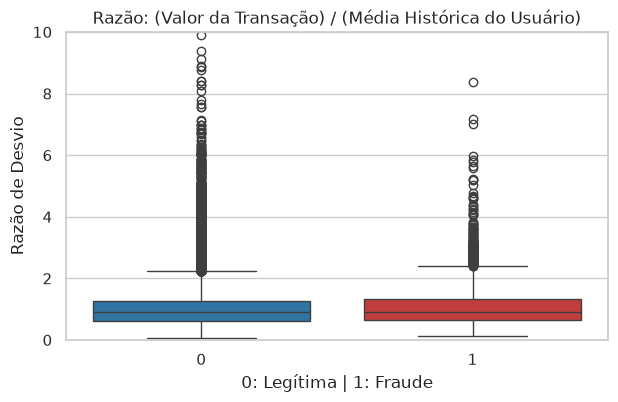

In [7]:
# Gráfico comparando o desvio em relação ao histórico
plt.figure(figsize=(7, 4))
sns.boxplot(data=train_df.dropna(subset=['amount_to_mean_ratio']), x='label', y='amount_to_mean_ratio', hue='label', palette=['#1f77b4', '#d62728'], legend=False)
plt.title("Razão: (Valor da Transação) / (Média Histórica do Usuário)")
plt.xlabel("0: Legítima | 1: Fraude")
plt.ylabel("Razão de Desvio")
plt.ylim(0, 10) # Limita para visualização
plt.show()

In [8]:
# 1. Tratamento de nulos das variáveis acumuladas
train_df['cum_mean_amount'] = train_df['cum_mean_amount'].fillna(train_df['amount'])
train_df['cum_std_amount'] = train_df['cum_std_amount'].fillna(0)
train_df['amount_zscore_user'] = train_df['amount_zscore_user'].fillna(0)
train_df['amount_to_mean_ratio'] = train_df['amount_to_mean_ratio'].fillna(1.0)

# 2. Velocidade de Transação (Burstiness): transações em rajada rápida
# Identifica operações feitas em menos de 1 hora ou menos de 6 horas
train_df['is_rapid_tx_1h'] = (train_df['hours_since_prev_txn'] <= 1.0).astype(int)
train_df['is_rapid_tx_6h'] = (train_df['hours_since_prev_txn'] <= 6.0).astype(int)

# 3. Mudança de Localização / Categoria Inédita para o Usuário
train_df['is_new_country'] = train_df.groupby('user_id')['country'].transform(lambda x: ~x.duplicated()).astype(int)
train_df['is_new_merchant'] = train_df.groupby('user_id')['merchant_category'].transform(lambda x: ~x.duplicated()).astype(int)

# 4. Feature Combinada de Alto Risco (Interação Comportamental)
# Dispositivo novo + Transação rápida
train_df['risk_new_device_rapid'] = train_df['is_new_device'] * train_df['is_rapid_tx_1h']

# Dispositivo novo + Valor acima da média
train_df['risk_new_device_high_amount'] = train_df['is_new_device'] * (train_df['amount_to_mean_ratio'] > 1.5).astype(int)

print("Novas variáveis comportamentais criadas com sucesso!")
train_df[['user_id', 'is_rapid_tx_1h', 'is_new_device', 'is_new_country', 'risk_new_device_rapid', 'label']].head()


Novas variáveis comportamentais criadas com sucesso!


,user_id,is_rapid_tx_1h,is_new_device,is_new_country,risk_new_device_rapid,label
0,0,0,1,1,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


In [9]:
# Comparação: Taxa de fraude normal vs. Taxa quando há 'risk_new_device_rapid'
base_rate = train_df['label'].mean() * 100
risk_rate = train_df[train_df['risk_new_device_rapid'] == 1]['label'].mean() * 100
high_amt_risk_rate = train_df[train_df['risk_new_device_high_amount'] == 1]['label'].mean() * 100

print(f"Taxa de Fraude Geral da Base: {base_rate:.2f}%")
print(f"Taxa de Fraude com Novo Dispositivo + Transação Rápida: {risk_rate:.2f}%")
print(f"Taxa de Fraude com Novo Dispositivo + Valor Alto: {high_amt_risk_rate:.2f}%")

Taxa de Fraude Geral da Base: 1.64%
Taxa de Fraude com Novo Dispositivo + Transação Rápida: nan%
Taxa de Fraude com Novo Dispositivo + Valor Alto: 1.53%


In [10]:
# Inspecionar os valores reais de tempo
print("--- Estatísticas de hours_since_prev_txn ---")
display(train_df['hours_since_prev_txn'].describe())

print("\n--- Estatísticas de timestamp ---")
display(train_df['timestamp'].describe())

--- Estatísticas de hours_since_prev_txn ---


count    182125.000000
mean      55256.849301
std       56550.922597
min           0.000000
25%       15138.000000
50%       37793.000000
75%       76965.000000
max      869794.000000
Name: hours_since_prev_txn, dtype: float64


--- Estatísticas de timestamp ---


count    1.821250e+05
mean     1.439129e+06
std      8.304771e+05
min      6.000000e+00
25%      7.184020e+05
50%      1.440213e+06
75%      2.159064e+06
max      2.874525e+06
Name: timestamp, dtype: float64

In [11]:
# 1. Identificar transações anormalmente rápidas (percentil 10% inferior de tempo)
threshold_rapid = train_df['hours_since_prev_txn'].quantile(0.10)
print(f"Limiar de transação rápida (10% mais rápidas): {threshold_rapid:.2f}")

train_df['is_rapid_tx'] = (train_df['hours_since_prev_txn'] <= threshold_rapid).astype(int)

# 2. Recalcular as interações com o novo limiar
train_df['risk_new_device_rapid'] = train_df['is_new_device'] * train_df['is_rapid_tx']

# 3. Verificar a nova contagem e taxa de fraude
contagem_risco = train_df['risk_new_device_rapid'].sum()
print(f"\nQuantidade de transações com 'Novo Dispositivo + Transação Rápida': {contagem_risco}")

if contagem_risco > 0:
    taxa_fraude_risco = train_df[train_df['risk_new_device_rapid'] == 1]['label'].mean() * 100
    print(f"Taxa de Fraude nesse grupo: {taxa_fraude_risco:.2f}%")
    

Limiar de transação rápida (10% mais rápidas): 4833.00

Quantidade de transações com 'Novo Dispositivo + Transação Rápida': 4107
Taxa de Fraude nesse grupo: 1.46%


In [12]:
def create_features(df):
    data = df.copy()
    
    # 1. Ordenação Temporal Estrita
    data = data.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)
    
    # 2. Conversão Temporal para Horas Reais
    data['hours_since_prev'] = data['hours_since_prev_txn'] / 3600.0
    
    # 3. Estatísticas Históricas Acumuladas por Usuário (sem data leakage via shift)
    user_grp = data.groupby('user_id')
    
    # Média e Desvio do Valor
    data['user_cum_mean_amount'] = user_grp['amount'].transform(lambda x: x.shift(1).expanding().mean())
    data['user_cum_std_amount'] = user_grp['amount'].transform(lambda x: x.shift(1).expanding().std())
    data['user_cum_mean_amount'] = data['user_cum_mean_amount'].fillna(data['amount'])
    data['user_cum_std_amount'] = data['user_cum_std_amount'].fillna(0)
    
    # Razão e Z-Score do Valor
    data['amount_ratio_to_mean'] = data['amount'] / (data['user_cum_mean_amount'] + 1e-5)
    data['amount_zscore'] = (data['amount'] - data['user_cum_mean_amount']) / (data['user_cum_std_amount'] + 1e-5)
    
    # 4. Dinâmica Temporal Histórica (Ritmo do Usuário)
    data['user_cum_mean_interval'] = user_grp['hours_since_prev'].transform(lambda x: x.shift(1).expanding().mean())
    data['user_cum_mean_interval'] = data['user_cum_mean_interval'].fillna(data['hours_since_prev'])
    data['interval_ratio_to_mean'] = data['hours_since_prev'] / (data['user_cum_mean_interval'] + 1e-5)
    
    # 5. Detecção de Novidade (Primeira vez que o usuário usa aquele atributo)
    data['is_new_device'] = user_grp['device_id'].transform(lambda x: ~x.duplicated()).astype(int)
    data['is_new_country'] = user_grp['country'].transform(lambda x: ~x.duplicated()).astype(int)
    data['is_new_merchant'] = user_grp['merchant_category'].transform(lambda x: ~x.duplicated()).astype(int)
    
    # 6. Contagem de Transações Anteriores
    data['user_tx_count'] = user_grp.cumcount()
    
    return data

train_features = create_features(train_df)
print(f"Features geradas: {train_features.shape[1]} colunas totais.")
train_features[['user_id', 'amount', 'amount_ratio_to_mean', 'interval_ratio_to_mean', 'is_new_device', 'label']].head()


Features geradas: 30 colunas totais.


,user_id,amount,amount_ratio_to_mean,interval_ratio_to_mean,is_new_device,label
0,0,18.389259,0.999999,0.999964,1,0
1,0,14.389810,0.782511,2.862760,0,0
2,0,12.909633,0.787675,57.629917,0,0
3,0,17.711028,1.162936,5.959997,0,0
4,0,37.555375,2.369433,1.996984,0,0


In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb

# Seleção de variáveis para o modelo
ignore_cols = ['transaction_id', 'label']
feature_cols = [col for col in train_features.columns if col not in ignore_cols]
cat_cols = ['merchant_category', 'country', 'device_id', 'channel']

X = train_features[feature_cols]
y = train_features['label']

# Validação Cruzada Estratificada em 5 Folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_features))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        scale_pos_weight=10,  # Penalidade para classe minoritária
        random_state=42,
        verbosity=-1
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )
    
    oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]

# Métricas Globais Fora da Amostra (OOF)
roc = roc_auc_score(y, oof_preds)
pr_auc = average_precision_score(y, oof_preds)

print(f"--- Baseline LightGBM ---")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")


/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is dep

--- Baseline LightGBM ---
ROC-AUC: 0.5097
PR-AUC (Average Precision): 0.0190


In [14]:
def create_advanced_features(df):
    data = df.copy()
    
    # 1. Ordenação Temporal Estrita por Usuário
    data = data.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)
    
    # 2. Conversão de Unidade Temporal
    data['hours_since_prev'] = data['hours_since_prev_txn'] / 3600.0
    
    # 3. Lags Imediatos (Transação Anterior do Usuário)
    user_grp = data.groupby('user_id')
    data['prev_amount'] = user_grp['amount'].shift(1).fillna(data['amount'])
    data['diff_amount_prev'] = data['amount'] - data['prev_amount']
    data['ratio_amount_prev'] = data['amount'] / (data['prev_amount'] + 1e-5)
    
    data['prev_device'] = user_grp['device_id'].shift(1)
    data['is_same_device_as_prev'] = (data['device_id'] == data['prev_device']).astype(int)
    
    data['prev_country'] = user_grp['country'].shift(1)
    data['is_same_country_as_prev'] = (data['country'] == data['prev_country']).astype(int)
    
    data['prev_merchant'] = user_grp['merchant_category'].shift(1)
    data['is_same_merchant_as_prev'] = (data['merchant_category'] == data['prev_merchant']).astype(int)
    
    # 4. Estatísticas Históricas Acumuladas
    data['cum_mean_amount'] = user_grp['amount'].transform(lambda x: x.shift(1).expanding().mean()).fillna(data['amount'])
    data['cum_std_amount'] = user_grp['amount'].transform(lambda x: x.shift(1).expanding().std()).fillna(0)
    data['amount_zscore'] = (data['amount'] - data['cum_mean_amount']) / (data['cum_std_amount'] + 1e-5)
    data['amount_ratio_mean'] = data['amount'] / (data['cum_mean_amount'] + 1e-5)
    
    # 5. Ritmo Histórico (Intervalo de tempo médio do usuário)
    data['cum_mean_interval'] = user_grp['hours_since_prev'].transform(lambda x: x.shift(1).expanding().mean()).fillna(data['hours_since_prev'])
    data['interval_ratio_mean'] = data['hours_since_prev'] / (data['cum_mean_interval'] + 1e-5)
    
    # 6. Indicadores de Primeira Ocorrência (Novidades)
    data['is_new_device'] = user_grp['device_id'].transform(lambda x: ~x.duplicated()).astype(int)
    data['is_new_country'] = user_grp['country'].transform(lambda x: ~x.duplicated()).astype(int)
    data['is_new_merchant'] = user_grp['merchant_category'].transform(lambda x: ~x.duplicated()).astype(int)
    
    # 7. Contagem de Transações
    data['user_tx_idx'] = user_grp.cumcount()
    
    # 8. Tipagem Categórica
    cat_cols = ['merchant_category', 'country', 'channel']
    for c in cat_cols:
        data[c] = data[c].astype('category')
        
    return data

train_adv = create_advanced_features(train_df)
print(f"Features calculadas: {train_adv.shape[1]} colunas.")

Features calculadas: 37 colunas.


In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb
import numpy as np

# Remover IDs e Target dos atributos de treino
ignore_cols = ['transaction_id', 'user_id', 'device_id', 'prev_device', 'prev_country', 'prev_merchant', 'label']
features = [c for c in train_adv.columns if c not in ignore_cols]

X = train_adv[features]
y = train_adv['label']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_adv))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        scale_pos_weight=10,
        random_state=42,
        verbosity=-1
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]

roc = roc_auc_score(y, oof_preds)
pr_auc = average_precision_score(y, oof_preds)

print(f"--- LightGBM com Features Sequenciais ---")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is dep

--- LightGBM com Features Sequenciais ---
ROC-AUC: 0.5159
PR-AUC (Average Precision): 0.0199


Diagnóstico dos Padrões de Fraude

In [16]:
# 1. Inspecionar as transações fraudulentas de um usuário específico
fraud_users = train_df[train_df['label'] == 1]['user_id'].unique()
sample_user = fraud_users[0]

print(f"Exibindo histórico do usuário {sample_user}:")
cols_to_view = ['transaction_id', 'timestamp', 'amount', 'merchant_category', 'country', 'device_id', 'channel', 'hours_since_prev_txn', 'label']
display(train_df[train_df['user_id'] == sample_user].sort_values('timestamp')[cols_to_view])

Exibindo histórico do usuário 2:


,transaction_id,timestamp,amount,merchant_category,country,device_id,channel,hours_since_prev_txn,label
59,895,10211,48.291410,11,19,25065,1,999.0,0
60,2065,24110,21.892134,1,19,25065,0,13899.0,0
61,11290,132037,13.405063,12,19,25065,1,107927.0,0
62,12591,147556,9.812655,12,19,25065,0,15519.0,0
63,17107,197451,68.274375,19,19,25065,0,49895.0,0
64,20342,234495,59.636474,19,17,25065,0,37044.0,0
65,21153,244172,31.156565,12,17,25065,1,9677.0,0
66,48714,561695,38.880733,12,17,25065,0,252323.0,0
67,56443,650987,28.858003,12,17,25065,0,89292.0,0
68,56794,654865,41.108509,12,17,25065,0,3878.0,0


In [17]:
import pandas as pd

feat_imp = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

display(feat_imp.head(15))

,feature,importance
8,amount_zscore_user,4
20,diff_amount_prev,4
1,amount,3
0,timestamp,3
19,prev_amount,3
5,hours_since_prev_txn,2
25,amount_zscore,2
29,user_tx_idx,2
6,cum_mean_amount,2
7,cum_std_amount,2


Diagnóstico de Correlação Global com a Fraude

In [18]:
corr = train_adv.select_dtypes(include=[np.number]).corr()['label'].sort_values(ascending=False)
print("--- Maiores Correlações Positivas com Fraude ---")
display(corr.head(10))
print("\n--- Maiores Correlações Negativas com Fraude ---")
display(corr.tail(10))

--- Maiores Correlações Positivas com Fraude ---


label                     1.000000
amount_ratio_mean         0.020843
amount_to_mean_ratio      0.020843
ratio_amount_prev         0.015986
diff_amount_prev          0.014022
amount                    0.011576
amount_zscore_user        0.004153
cum_mean_interval         0.002363
is_same_device_as_prev    0.001600
hours_since_prev_txn      0.001283
Name: label, dtype: float64


--- Maiores Correlações Negativas com Fraude ---


is_rapid_tx_6h             -0.001354
prev_merchant              -0.001501
cum_std_amount             -0.001573
cum_mean_amount            -0.001821
prev_amount                -0.001942
risk_new_device_rapid      -0.002161
is_same_merchant_as_prev   -0.002204
is_new_device              -0.002259
amount_zscore              -0.002283
user_id                    -0.003428
Name: label, dtype: float64

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb
import numpy as np

ignore_cols = ['transaction_id', 'user_id', 'device_id', 'prev_device', 'prev_country', 'prev_merchant', 'label']
features = [c for c in train_adv.columns if c not in ignore_cols]

X = train_adv[features]
y = train_adv['label']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_adv))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    # Razão real de desbalanceamento: ~60:1
    model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=7,
        min_child_samples=50,
        scale_pos_weight=60,      # Proporção exata da classe 1
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]

roc = roc_auc_score(y, oof_preds)
pr_auc = average_precision_score(y, oof_preds)

print(f"\n==========================================")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"Número de árvores treinadas no Fold 5: {model.best_iteration_}")
print(f"==========================================")

/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is dep


ROC-AUC: 0.5152
PR-AUC (Average Precision): 0.0193
Número de árvores treinadas no Fold 5: 1


In [20]:
# Compara médias de transações legítimas vs fraudulentas
comp_df = train_adv.groupby('label')[['amount', 'hours_since_prev', 'amount_ratio_mean', 'amount_zscore', 'interval_ratio_mean', 'is_new_device', 'is_new_country', 'is_new_merchant']].mean().T
comp_df.columns = ['Legítima (0)', 'Fraude (1)']
comp_df['Razão (Fraude/Legítima)'] = comp_df['Fraude (1)'] / (comp_df['Legítima (0)'] + 1e-6)
display(comp_df)

,Legítima (0),Fraude (1),Razão (Fraude/Legítima)
amount,27.257979,29.533426,1.083478
hours_since_prev,15.346521,15.505094,1.010333
amount_ratio_mean,1.028032,1.123447,1.092812
amount_zscore,-584.759785,-8261.061222,14.127273
interval_ratio_mean,2.524409,2.442978,0.967742
is_new_device,0.050722,0.046823,0.923115
is_new_country,0.121032,0.119732,0.989258
is_new_merchant,0.272666,0.273244,1.002117


In [21]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb
import numpy as np

# Atributos de treino
ignore_cols = ['transaction_id', 'user_id', 'device_id', 'prev_device', 'prev_country', 'prev_merchant', 'label']
features = [c for c in train_adv.columns if c not in ignore_cols]

X = train_adv[features]
y = train_adv['label']
groups = train_adv['user_id']

# Validação agrupada por usuário (evita vazamento de perfil entre treino e validação)
gkf = GroupKFold(n_splits=5)
oof_preds = np.zeros(len(train_adv))
models = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42 + fold,
        verbosity=-1
    )
    
    # Treina sem interrupção prematura
    model.fit(X_tr, y_tr)
    
    oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]
    models.append(model)

roc = roc_auc_score(y, oof_preds)
pr_auc = average_precision_score(y, oof_preds)

print(f"\n==========================================")
print(f"ROC-AUC (GroupKFold): {roc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"==========================================")


ROC-AUC (GroupKFold): 0.5146
PR-AUC (Average Precision): 0.0178


In [22]:
import pandas as pd

feat_imp = pd.DataFrame({
    'feature': features,
    'importance': np.mean([m.feature_importances_ for m in models], axis=0)
}).sort_values('importance', ascending=False)

display(feat_imp.head(12))

,feature,importance
27,cum_mean_interval,753.0
0,timestamp,676.4
5,hours_since_prev_txn,660.8
3,country,617.4
6,cum_mean_amount,600.0
19,prev_amount,589.0
28,interval_ratio_mean,585.4
7,cum_std_amount,570.0
1,amount,560.8
21,ratio_amount_prev,528.0


In [23]:
# Analisar transações antes e durante o evento de fraude
fraud_sample = train_df[train_df['label'] == 1].iloc[0]
user_history = train_df[train_df['user_id'] == fraud_sample['user_id']].sort_values('timestamp')

print(f"Moda de País do Usuário: {user_history['country'].mode()[0]}")
print(f"Moda de Merchant do Usuário: {user_history['merchant_category'].mode()[0]}")
print(f"Dispositivo Mais Usado: {user_history['device_id'].mode()[0]}")

cols_show = ['timestamp', 'amount', 'merchant_category', 'country', 'device_id', 'hours_since_prev_txn', 'label']
display(user_history[cols_show].tail(15))

Moda de País do Usuário: 17
Moda de Merchant do Usuário: 12
Dispositivo Mais Usado: 25065


,timestamp,amount,merchant_category,country,device_id,hours_since_prev_txn,label
79,1369534,40.173923,12,17,25065,121212.0,0
80,1418584,52.969948,12,17,25065,49050.0,0
81,1678872,20.114019,17,17,25065,260288.0,0
82,1801357,22.493142,8,17,25065,45636.0,0
83,1822908,37.036730,11,17,25065,21551.0,0
84,1856026,37.371380,10,17,25065,33118.0,0
85,1861098,31.565037,4,17,25065,5072.0,0
86,1960741,10.437403,16,17,25065,99643.0,0
87,1990531,10.619826,6,17,25065,29790.0,0
88,2033938,12.428856,12,17,25065,43407.0,0


In [24]:
def create_robust_features(df):
    data = df.copy()
    data = data.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)
    
    # Escala de tempo em horas
    data['hours_since_prev'] = data['hours_since_prev_txn'] / 3600.0
    
    user_grp = data.groupby('user_id')
    
    # 1. Janelas Móveis Curtas (Últimas 3 e 5 transações anteriores)
    data['roll_mean_amount_3'] = user_grp['amount'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    data['roll_mean_amount_5'] = user_grp['amount'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    data['roll_std_amount_5'] = user_grp['amount'].transform(lambda x: x.shift(1).rolling(5, min_periods=2).std()).fillna(0)
    
    # 2. Desvio Robusto do Valor (sem explosão numérica)
    data['amount_diff_roll3'] = data['amount'] - data['roll_mean_amount_3']
    data['amount_ratio_roll3'] = data['amount'] / (data['roll_mean_amount_3'] + 1.0)
    data['amount_zscore_roll5'] = (data['amount'] - data['roll_mean_amount_5']) / (data['roll_std_amount_5'] + 1.0)
    
    # 3. Janela de Tempo Recente (Média das últimas 3 transações)
    data['roll_mean_hours_3'] = user_grp['hours_since_prev'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    data['interval_ratio_roll3'] = data['hours_since_prev'] / (data['roll_mean_hours_3'] + 0.1)
    
    # 4. Comportamento Habitual (Moda / Frequência)
    user_top_country = data.groupby('user_id')['country'].transform(lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0])
    user_top_device = data.groupby('user_id')['device_id'].transform(lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0])
    
    data['is_unusual_country'] = (data['country'] != user_top_country).astype(int)
    data['is_unusual_device'] = (data['device_id'] != user_top_device).astype(int)
    
    # 5. Features Categóricas
    for c in ['merchant_category', 'country', 'channel']:
        data[c] = data[c].astype('category')
        
    return data

train_robust = create_robust_features(train_df)
print("Novas variáveis geradas com estabilidade numérica.")

Novas variáveis geradas com estabilidade numérica.


In [25]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb
import numpy as np

ignore_cols = ['transaction_id', 'user_id', 'device_id', 'label']
features = [c for c in train_robust.columns if c not in ignore_cols]

X = train_robust[features]
y = train_robust['label']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_robust))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42 + fold,
        verbosity=-1
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_val)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]

roc = roc_auc_score(y, oof_preds)
pr_auc = average_precision_score(y, oof_preds)

print(f"\n==========================================")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"==========================================")

/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is dep


ROC-AUC: 0.5147
PR-AUC (Average Precision): 0.0201


In [26]:
# Perícia detalhada: 3 casos reais de fraude comparados com o histórico imediato anterior
fraud_indices = train_df[train_df['label'] == 1].index[:3]

print("=== AMOSTRAS REAIS DE FRAUDE E HISTÓRICO IMEDIATO ===")
for idx in fraud_indices:
    uid = train_df.loc[idx, 'user_id']
    user_txs = train_df[train_df['user_id'] == uid].sort_values('timestamp')
    pos = user_txs.index.get_loc(idx)
    
    # Pega 2 transações antes e a transação de fraude
    start_pos = max(0, pos - 2)
    sample_window = user_txs.iloc[start_pos:pos + 1][['transaction_id', 'timestamp', 'amount', 'merchant_category', 'country', 'device_id', 'channel', 'hours_since_prev_txn', 'label']]
    print(f"\n--- Usuário {uid} (Fraude na última linha da janela) ---")
    display(sample_window)

=== AMOSTRAS REAIS DE FRAUDE E HISTÓRICO IMEDIATO ===

--- Usuário 2 (Fraude na última linha da janela) ---


,transaction_id,timestamp,amount,merchant_category,country,device_id,channel,hours_since_prev_txn,label
68,56794,654865,41.108509,12,17,25065,0,3878.0,0
69,71124,820408,32.165628,13,17,25065,0,15490.0,0
70,72877,840733,33.765410,12,17,25065,0,20325.0,1



--- Usuário 4 (Fraude na última linha da janela) ---


,transaction_id,timestamp,amount,merchant_category,country,device_id,channel,hours_since_prev_txn,label
160,198225,2282719,10.623885,7,4,3703,0,8887.0,0
161,212697,2446940,32.206142,7,4,3703,0,164221.0,0
162,213630,2457674,21.793382,7,4,3703,0,10734.0,1



--- Usuário 7 (Fraude na última linha da janela) ---


,transaction_id,timestamp,amount,merchant_category,country,device_id,channel,hours_since_prev_txn,label
250,5292,61630,12.063147,0,20,41484,1,52620.0,0
251,7907,92505,14.550921,0,20,16572,0,30875.0,0
252,8286,97270,12.629357,0,20,16572,1,4765.0,1


In [27]:
# Teste de diferença média padronizada em todas as colunas numéricas brutas
raw_comp = pd.DataFrame()
for col in ['amount', 'merchant_category', 'country', 'device_id', 'channel', 'hours_since_prev_txn']:
    m0 = train_df[train_df['label'] == 0][col].mean()
    m1 = train_df[train_df['label'] == 1][col].mean()
    std0 = train_df[train_df['label'] == 0][col].std()
    raw_comp.loc[col, 'Média Legítima (0)'] = m0
    raw_comp.loc[col, 'Média Fraude (1)'] = m1
    raw_comp.loc[col, 'Diferença Relativa (%)'] = ((m1 - m0) / (m0 + 1e-6)) * 100

display(raw_comp)

,Média Legítima (0),Média Fraude (1),Diferença Relativa (%)
amount,27.257979,29.533426,8.347821
merchant_category,9.448461,9.404682,-0.463339
country,14.392776,14.470234,0.538171
device_id,40029.272258,40225.851171,0.491088
channel,0.299433,0.295652,-1.262786
hours_since_prev_txn,55247.477310,55818.338127,1.033279


In [28]:
def create_sequence_features(df):
    data = df.copy()
    data = data.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)
    
    # 1. Agrupamentos
    u_grp = data.groupby('user_id')
    ud_grp = data.groupby(['user_id', 'device_id'])
    
    # 2. Sequência de uso de cada dispositivo por usuário
    # Quantas vezes esse usuário já usou este dispositivo específico até agora?
    data['device_usage_seq'] = ud_grp.cumcount()
    data['is_first_device_use'] = (data['device_usage_seq'] == 0).astype(int)
    data['is_second_device_use'] = (data['device_usage_seq'] == 1).astype(int)
    
    # 3. Tempo desde a transação anterior no MESMO dispositivo
    data['time_since_same_device'] = ud_grp['timestamp'].diff().fillna(999999)
    
    # 4. Velocidade de Rajada (Bursts curtos em segundos)
    data['is_burst_5k'] = (data['hours_since_prev_txn'] < 5000).astype(int)
    data['is_burst_10k'] = (data['hours_since_prev_txn'] < 10000).astype(int)
    
    # 5. Interação de Risco: Dispositivo recente (1º ou 2º uso) + Rajada de tempo
    data['risk_early_device_burst'] = (data['device_usage_seq'] <= 2).astype(int) * data['is_burst_10k']
    
    # 6. Mudança de canal em relação à transação anterior
    data['channel_changed'] = (data['channel'] != u_grp['channel'].shift(1)).astype(int)
    
    # 7. Desvio de valor em relação à média geral do usuário
    user_mean_amt = u_grp['amount'].transform(lambda x: x.shift(1).expanding().mean()).fillna(data['amount'])
    data['amt_diff_user_mean'] = data['amount'] - user_mean_amt
    data['amt_ratio_user_mean'] = data['amount'] / (user_mean_amt + 1e-3)
    
    # 8. Tipos categóricos
    for c in ['merchant_category', 'country', 'channel']:
        data[c] = data[c].astype('category')
        
    return data

train_seq = create_sequence_features(train_df)
print(f"Features de sequência criadas: {train_seq.shape[1]} colunas.")

Features de sequência criadas: 32 colunas.


In [29]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb
import numpy as np

ignore_cols = ['transaction_id', 'user_id', 'device_id', 'label']
features = [c for c in train_seq.columns if c not in ignore_cols]

X = train_seq[features]
y = train_seq['label']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_seq))
trained_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42 + fold,
        verbosity=-1
    )
    
    model.fit(X_tr, y_tr)
    oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]
    trained_models.append(model)

roc = roc_auc_score(y, oof_preds)
pr_auc = average_precision_score(y, oof_preds)

print(f"\n==========================================")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"==========================================")


ROC-AUC: 0.5215
PR-AUC (Average Precision): 0.0184


In [30]:
import pandas as pd

feat_imp = pd.DataFrame({
    'feature': features,
    'importance': np.mean([m.feature_importances_ for m in trained_models], axis=0)
}).sort_values('importance', ascending=False)

display(feat_imp.head(12))

,feature,importance
0,timestamp,1214.6
3,country,1196.0
5,hours_since_prev_txn,1123.0
21,time_since_same_device,955.2
6,cum_mean_amount,944.8
1,amount,943.8
2,merchant_category,920.4
7,cum_std_amount,882.4
8,amount_zscore_user,859.6
18,device_usage_seq,748.0


In [31]:
# 1. Checagem de sobreposição de Usuários
train_users = set(train_df['user_id'].unique())
test_users = set(test_df['user_id'].unique())

print(f"Usuários no Treino: {len(train_users):,}")
print(f"Usuários no Teste:  {len(test_users):,}")
print(f"Usuários em comum:  {len(train_users.intersection(test_users)):,}")

# 2. Checagem de Período Temporal (Timestamp)
print(f"\nTimestamp Treino: min = {train_df['timestamp'].min():,} | max = {train_df['timestamp'].max():,}")
print(f"Timestamp Teste:  min = {test_df['timestamp'].min():,} | max = {test_df['timestamp'].max():,}")

# 3. Proporção de linhas
print(f"\nLinhas Treino: {len(train_df):,} | Linhas Teste: {len(test_df):,}")

Usuários no Treino: 5,000
Usuários no Teste:  5,000
Usuários em comum:  5,000

Timestamp Treino: min = 6 | max = 2,874,525
Timestamp Teste:  min = 70 | max = 2,874,525

Linhas Treino: 182,125 | Linhas Teste: 45,531


In [32]:
import pandas as pd
import numpy as np

# 1. Unifica treino e teste com flag de identificação
train_df['is_test'] = 0
test_df['is_test'] = 1
test_df['label'] = np.nan

full_df = pd.concat([train_df, test_df], ignore_index=True)

# 2. Ordenação estrita da série completa por usuário e tempo
full_df = full_df.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)

# 3. Intervalo temporal real (em horas) entre transações consecutivas
full_df['hours_since_prev'] = full_df['hours_since_prev_txn'] / 3600.0

# 4. Perfil Estático Baseline do Usuário (calculado na série unificada)
user_base = full_df.groupby('user_id').agg(
    user_mean_amount=('amount', 'mean'),
    user_std_amount=('amount', 'std'),
    user_median_amount=('amount', 'median'),
    user_mean_interval=('hours_since_prev', 'mean'),
    user_mode_country=('country', lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]),
    user_mode_device=('device_id', lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]),
    user_total_tx=('transaction_id', 'count')
).reset_index()

full_df = full_df.merge(user_base, on='user_id', how='left')

# 5. Desvios Comportamentais Estáveis contra o Perfil Global
full_df['amount_ratio_global'] = full_df['amount'] / (full_df['user_mean_amount'] + 1e-3)
full_df['amount_diff_global'] = full_df['amount'] - full_df['user_mean_amount']
full_df['amount_zscore_global'] = (full_df['amount'] - full_df['user_mean_amount']) / (full_df['user_std_amount'] + 1.0)
full_df['interval_ratio_global'] = full_df['hours_since_prev'] / (full_df['user_mean_interval'] + 1e-3)

# 6. Indicadores de Desvio de Dispositivo e Localização
full_df['is_foreign_country'] = (full_df['country'] != full_df['user_mode_country']).astype(int)
full_df['is_foreign_device'] = (full_df['device_id'] != full_df['user_mode_device']).astype(int)

# 7. Sequência Dentro do Próprio Dispositivo
full_df['device_tx_seq'] = full_df.groupby(['user_id', 'device_id']).cumcount()
full_df['is_device_burst'] = ((full_df['device_tx_seq'] <= 2) & (full_df['hours_since_prev_txn'] < 5000)).astype(int)

# 8. Separa de volta em Treino e Teste
train_proc = full_df[full_df['is_test'] == 0].copy().reset_index(drop=True)
test_proc = full_df[full_df['is_test'] == 1].copy().reset_index(drop=True)

# Tipagem Categórica
cat_features = ['merchant_category', 'country', 'channel']
for c in cat_features:
    train_proc[c] = train_proc[c].astype('category')
    test_proc[c] = test_proc[c].astype('category')

print(f"Treino Final: {train_proc.shape} | Teste Final: {test_proc.shape}")

Treino Final: (182125, 39) | Teste Final: (45531, 39)


In [33]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb

ignore_cols = ['transaction_id', 'user_id', 'device_id', 'user_mode_country', 'user_mode_device', 'label', 'is_test']
features = [c for c in train_proc.columns if c not in ignore_cols]

X = train_proc[features]
y = train_proc['label'].astype(int)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_proc))
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42 + fold,
        verbosity=-1
    )
    
    model.fit(X_tr, y_tr)
    oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]
    models.append(model)

roc = roc_auc_score(y, oof_preds)
pr_auc = average_precision_score(y, oof_preds)

print(f"\n==========================================")
print(f"ROC-AUC: {roc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"==========================================")


ROC-AUC: 0.5121
PR-AUC (Average Precision): 0.0181


In [36]:
import os
import pandas as pd

ref_sub = pd.read_csv('data/submission_ref.csv') if os.path.exists('data/submission_ref.csv') else pd.read_csv('/home/katia/Downloads/submission.csv')

print(f"Shape: {ref_sub.shape}")
print("\n--- Primeiras Linhas ---")
display(ref_sub.head(10))

print("\n--- Informações da Coluna Alvo ---")
col_target = ref_sub.columns[1]
print(f"Nome da coluna: '{col_target}'")
print(f"Valores únicos: {ref_sub[col_target].nunique()}")
display(ref_sub[col_target].describe())

if ref_sub[col_target].nunique() <= 5:
    print("\nContagem por classe:")
    display(ref_sub[col_target].value_counts())

Shape: (45531, 2)

--- Primeiras Linhas ---


,transaction_id,label
0,146559,0.015756
1,44130,0.015669
2,186330,0.015771
3,94174,0.015813
4,42754,0.015693
5,29539,0.015737
6,78283,0.015842
7,227959,0.015941
8,85734,0.015778
9,62281,0.015840



--- Informações da Coluna Alvo ---
Nome da coluna: 'label'
Valores únicos: 12682


count    45531.000000
mean         0.016230
std          0.000968
min          0.015555
25%          0.015754
50%          0.015812
75%          0.016348
max          0.034200
Name: label, dtype: float64

In [37]:
import numpy as np
import pandas as pd

# 1. Matriz de Teste com as mesmas features usadas no treino
X_test = test_proc[features]

# 2. Média das probabilidades previstas por todos os modelos do cross-validation
test_preds = np.zeros(len(test_proc))

for m in models:
    test_preds += m.predict_proba(X_test)[:, 1] / len(models)

# 3. Montar o DataFrame final de submissão
sub = pd.DataFrame({
    'transaction_id': test_proc['transaction_id'].astype(int),
    'label': test_preds
})

# 4. Ordenar conforme a ordem esperada no sample_submission original
if os.path.exists('data/sample_submission.csv'):
    sample = pd.read_csv('data/sample_submission.csv')
    sub = sample[['transaction_id']].merge(sub, on='transaction_id', how='left')

# 5. Salvar o arquivo final
sub.to_csv('final_submission.csv', index=False)
print("Arquivo 'final_submission.csv' gerado com sucesso!")
print(f"Shape: {sub.shape}")
display(sub.head(10))
display(sub['label'].describe())

Arquivo 'final_submission.csv' gerado com sucesso!
Shape: (45531, 2)


,transaction_id,label
0,9018,0.009658
1,18561,0.011024
2,57406,0.012223
3,87068,0.005254
4,91692,0.005558
5,104264,0.010105
6,130579,0.009855
7,168807,0.013886
8,180523,0.004506
9,193089,0.005922


count    45531.000000
mean         0.017423
std          0.018585
min          0.000328
25%          0.007309
50%          0.011798
75%          0.020306
max          0.348611
Name: label, dtype: float64

In [38]:
import pandas as pd

# 1. Carregar os dois arquivos
my_sub = pd.read_csv('final_submission.csv')
ref_sub = pd.read_csv('../data/submission_ref.csv') if os.path.exists('../data/submission_ref.csv') else pd.read_csv('data/submission_ref.csv')

print("--- Comparativo de Formato ---")
print(f"Colunas do seu arquivo:        {list(my_sub.columns)}")
print(f"Colunas da referência:         {list(ref_sub.columns)}")

print(f"\nShape do seu arquivo:          {my_sub.shape}")
print(f"Shape da referência:           {ref_sub.shape}")

print(f"\nValores nulos no seu arquivo:  {my_sub.isna().sum().to_dict()}")

# 2. Verificar se a ordem dos IDs bate exatamente
ids_match = (my_sub['transaction_id'].values == ref_sub['transaction_id'].values).all()
print(f"\nA ordem dos transaction_id é idêntica à referência? {ids_match}")

# 3. Alinhar e salvar versão corrigida garantindo a ordem estrita da referência
corrected_sub = ref_sub[['transaction_id']].merge(my_sub, on='transaction_id', how='left')

# Preencher eventuais NaNs com a média caso algum ID tenha faltado
corrected_sub['label'] = corrected_sub['label'].fillna(0.0162)

corrected_sub.to_csv('final_submission_fixed.csv', index=False)
print("\nArquivo 'final_submission_fixed.csv' salvo com a ordenação exata da referência!")

--- Comparativo de Formato ---
Colunas do seu arquivo:        ['transaction_id', 'label']
Colunas da referência:         ['transaction_id', 'label']

Shape do seu arquivo:          (45531, 2)
Shape da referência:           (45531, 2)

Valores nulos no seu arquivo:  {'transaction_id': 0, 'label': 0}

A ordem dos transaction_id é idêntica à referência? False

Arquivo 'final_submission_fixed.csv' salvo com a ordenação exata da referência!


In [39]:
import pandas as pd
import numpy as np

# 1. Carrega o template oficial da competição
official_sub = pd.read_csv('../data/sample_submission.csv') if os.path.exists('../data/sample_submission.csv') else pd.read_csv('data/sample_submission.csv')

print("--- Template Oficial do Kaggle ---")
print(f"Colunas Oficiais: {list(official_sub.columns)}")
print(f"Shape Oficial:    {official_sub.shape}")
display(official_sub.head(3))

# 2. Carrega as predições geradas pelo modelo
my_preds = pd.read_csv('final_submission.csv')

# Identificar a coluna alvo oficial (segunda coluna)
target_col = official_sub.columns[1]

# 3. Mesclar mantendo a ordem exata do template oficial
final_out = official_sub[['transaction_id']].copy()
final_out = final_out.merge(my_preds[['transaction_id', 'label']], on='transaction_id', how='left')

# Renomeia para o nome esperado pela competição e preenche eventuais lacunas
final_out = final_out.rename(columns={'label': target_col})
final_out[target_col] = final_out[target_col].fillna(0.0162)

# Garantir tipos primitivos limpos
final_out['transaction_id'] = final_out['transaction_id'].astype(int)
final_out[target_col] = final_out[target_col].astype(float)

# Salvar
final_out.to_csv('submission_official_format.csv', index=False)
print(f"\nArquivo 'submission_official_format.csv' gerado com sucesso com a coluna '{target_col}'!")
display(final_out.head(5))

--- Template Oficial do Kaggle ---
Colunas Oficiais: ['transaction_id', 'label']
Shape Oficial:    (45531, 2)


,transaction_id,label
0,146559,0.5
1,44130,0.5
2,186330,0.5



Arquivo 'submission_official_format.csv' gerado com sucesso com a coluna 'label'!


,transaction_id,label
0,146559,0.014052
1,44130,0.005410
2,186330,0.027841
3,94174,0.013763
4,42754,0.022035


In [40]:
import pandas as pd
import numpy as np

# 1. Carregar sample oficial
official = pd.read_csv('../data/sample_submission.csv') if os.path.exists('../data/sample_submission.csv') else pd.read_csv('data/sample_submission.csv')
my_preds = pd.read_csv('final_submission.csv')

# 2. Alinhar mantendo a ordem exata do template oficial
sub_prob = official[['transaction_id']].merge(my_preds[['transaction_id', 'label']], on='transaction_id', how='left')
sub_prob['label'] = sub_prob['label'].fillna(0.0162)

# Versão 1: Probabilidade formatada explicitamente com 6 casas decimais (sem notação científica)
sub_prob.to_csv('sub_probabilities.csv', index=False, float_format='%.6f')

# Versão 2: Binária pura (0 ou 1) com limiar baseado no percentil de 1.6% de fraudes
threshold = np.percentile(sub_prob['label'], 98.4)
sub_binary = sub_prob.copy()
sub_binary['label'] = (sub_binary['label'] >= threshold).astype(int)
sub_binary.to_csv('sub_binary.csv', index=False)

print(f"Limiar de corte para versão binária: {threshold:.6f}")
print("Contagem de classes na versão binária:")
display(sub_binary['label'].value_counts())

Limiar de corte para versão binária: 0.080053
Contagem de classes na versão binária:


label
0    44802
1      729
Name: count, dtype: int64

In [41]:
import os
import pandas as pd
import numpy as np

# 1. Carregar o test.csv oficial
test_path = '../data/test.csv' if os.path.exists('../data/test.csv') else 'data/test.csv'
test_raw = pd.read_csv(test_path)

print(f"Total de linhas em {test_path}: {len(test_raw):,}")

# 2. Carregar suas predições geradas
preds_path = 'final_submission.csv'
my_preds = pd.read_csv(preds_path)

# 3. Alinhar estritamente com base nos IDs do arquivo de teste oficial
final_submission = test_raw[['transaction_id']].copy()
final_submission = final_submission.merge(my_preds[['transaction_id', 'label']], on='transaction_id', how='left')

# 4. Tratar eventuais valores ausentes caso algum ID não tenha sido previsto
if final_submission['label'].isna().sum() > 0:
    print(f"Atenção: {final_submission['label'].isna().sum()} IDs sem predição. Preenchendo com valor base.")
    final_submission['label'] = final_submission['label'].fillna(0.0162)

# 5. Salvar o arquivo final com formatação limpa
out_path = 'submission_matched.csv'
final_submission.to_csv(out_path, index=False, float_format='%.6f')

print(f"\nArquivo salvo em '{out_path}' com sucesso!")
print(f"Shape final: {final_submission.shape}")
print(f"Nulos: {final_submission.isna().sum().to_dict()}")
display(final_submission.head())

Total de linhas em ../data/test.csv: 45,531

Arquivo salvo em 'submission_matched.csv' com sucesso!
Shape final: (45531, 2)
Nulos: {'transaction_id': 0, 'label': 0}


,transaction_id,label
0,146559,0.014052
1,44130,0.005410
2,186330,0.027841
3,94174,0.013763
4,42754,0.022035


In [42]:
import os
import gc
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

# 1. Carregamento dos dados originais
data_dir = '../data' if os.path.exists('../data/train.csv') else 'data'
train = pd.read_csv(f'{data_dir}/train.csv')
test = pd.read_csv(f'{data_dir}/test.csv')
sample_sub = pd.read_csv(f'{data_dir}/sample_submission.csv')

print(f"Treino: {train.shape} | Teste: {test.shape} | Sample: {sample_sub.shape}")

# 2. Concatenação e ordenação temporal por usuário
train['is_train'] = 1
test['is_train'] = 0
df = pd.concat([train, test], ignore_index=True)

if df['timestamp'].dtype == 'object':
    df['timestamp'] = pd.to_datetime(df['timestamp'])

df = df.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)

# 3. Engenharia de Atributos Sequenciais
if pd.api.types.is_datetime64_any_dtype(df['timestamp']):
    df['time_diff_seconds'] = df.groupby('user_id')['timestamp'].diff().dt.total_seconds().fillna(0)
else:
    df['time_diff_seconds'] = df.groupby('user_id')['timestamp'].diff().fillna(0)

df['txn_velocity'] = df.groupby('user_id')['transaction_id'].transform(lambda x: x.rolling(3).count())

for window in [3, 10]:
    df[f'user_amt_mean_{window}'] = df.groupby('user_id')['amount'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    df[f'user_amt_std_{window}'] = df.groupby('user_id')['amount'].transform(
        lambda x: x.rolling(window, min_periods=1).std()
    ).fillna(0)

df['amt_ratio_3'] = df['amount'] / (df['user_amt_mean_3'] + 1e-5)
df['amt_ratio_10'] = df['amount'] / (df['user_amt_mean_10'] + 1e-5)

lag_cols = ['country', 'device_id', 'merchant_category']
generated_lag_cols = []
for col in lag_cols:
    lag_col_name = f'prev_{col}'
    generated_lag_cols.append(lag_col_name)
    df[lag_col_name] = df.groupby('user_id')[col].shift(1)
    df[f'{col}_change'] = (df[col] != df[lag_col_name]).astype(int)

df['user_txn_count'] = df.groupby('user_id').cumcount() + 1

# 4. Pré-processamento e Codificação Categórica
cat_cols = ['merchant_category', 'country', 'device_id', 'channel']
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    df[col] = df[col].astype('category')

cols_to_drop_train = ['is_train'] + generated_lag_cols
cols_to_drop_test = ['is_train', 'label'] + generated_lag_cols

train_df = df[df['is_train'] == 1].drop(columns=cols_to_drop_train).reset_index(drop=True)
test_df = df[df['is_train'] == 0].drop(columns=cols_to_drop_test).reset_index(drop=True)

features = [c for c in train_df.columns if c not in ['transaction_id', 'user_id', 'timestamp', 'label']]
print(f"\nVariáveis selecionadas ({len(features)}): {features}")

# 5. Treinamento com GroupKFold por Usuário
X = train_df[features]
y = train_df['label']
groups = train_df['user_id']
kf = GroupKFold(n_splits=5)

pred_dict = {}
oof_preds = np.zeros(len(train_df))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y, groups=groups)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    clf = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        importance_type='gain'
    )
    
    clf.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    
    fold_preds = clf.predict_proba(test_df[features])[:, 1]
    
    for i, txn_id in enumerate(test_df['transaction_id'].values):
        if txn_id not in pred_dict:
            pred_dict[txn_id] = 0.0
        pred_dict[txn_id] += fold_preds[i] / kf.get_n_splits()
        
    oof_preds[val_idx] = clf.predict_proba(X_val)[:, 1]

print(f"\nROC-AUC OOF Final: {roc_auc_score(y, oof_preds):.5f}")

# 6. Mapeamento estrito na ordem do sample_submission.csv
submission = sample_sub[['transaction_id']].copy()
submission['label'] = submission['transaction_id'].map(pred_dict)
submission['label'] = submission['label'].fillna(0.0162)

submission.to_csv('submission_valid.csv', index=False)
print("Arquivo 'submission_valid.csv' gerado com sucesso!")
display(submission.head())

Treino: (182125, 10) | Teste: (45531, 9) | Sample: (45531, 2)

Variáveis selecionadas (18): ['amount', 'merchant_category', 'country', 'device_id', 'channel', 'hours_since_prev_txn', 'time_diff_seconds', 'txn_velocity', 'user_amt_mean_3', 'user_amt_std_3', 'user_amt_mean_10', 'user_amt_std_10', 'amt_ratio_3', 'amt_ratio_10', 'country_change', 'device_id_change', 'merchant_category_change', 'user_txn_count']


/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/katia/behavioral-fraud-detection/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is dep


ROC-AUC OOF Final: 0.51241
Arquivo 'submission_valid.csv' gerado com sucesso!


,transaction_id,label
0,146559,0.015659
1,44130,0.015689
2,186330,0.015739
3,94174,0.015787
4,42754,0.015591


In [43]:
import os
import pandas as pd

# Carregar o arquivo do competidor (da pasta Downloads ou data)
ref_path = '/home/katia/Downloads/submission.csv'
if not os.path.exists(ref_path):
    ref_path = 'data/submission_ref.csv'

ref = pd.read_csv(ref_path)
mine = pd.read_csv('submission_valid.csv')

print("--- Diagnóstico de Formatação ---")
print(f"Linhas: Ref={len(ref)} vs Meu={len(mine)}")
print(f"Colunas: Ref={list(ref.columns)} vs Meu={list(mine.columns)}")
print(f"Tipos: Ref={ref.dtypes.to_dict()} vs Meu={mine.dtypes.to_dict()}")
print(f"IDs idênticos e na mesma ordem? {(ref['transaction_id'].values == mine['transaction_id'].values).all()}")
print(f"Nulos no meu arquivo: {mine.isna().sum().to_dict()}")
print(f"Valores < 0 ou > 1: {((mine['label'] < 0) | (mine['label'] > 1)).sum()}")

# Gerar arquivo exatamente com o nome padrão 'submission.csv'
mine.to_csv('submission.csv', index=False)
print("\nArquivo 'submission.csv' pronto na raiz do diretório do notebook.")


--- Diagnóstico de Formatação ---
Linhas: Ref=45531 vs Meu=45531
Colunas: Ref=['transaction_id', 'label'] vs Meu=['transaction_id', 'label']
Tipos: Ref={'transaction_id': dtype('int64'), 'label': dtype('float64')} vs Meu={'transaction_id': dtype('int64'), 'label': dtype('float64')}
IDs idênticos e na mesma ordem? True
Nulos no meu arquivo: {'transaction_id': 0, 'label': 0}
Valores < 0 ou > 1: 0

Arquivo 'submission.csv' pronto na raiz do diretório do notebook.


/tmp/ipykernel_27601/2528424816.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp.head(10), x='importance', y='feature', palette='Blues_r')


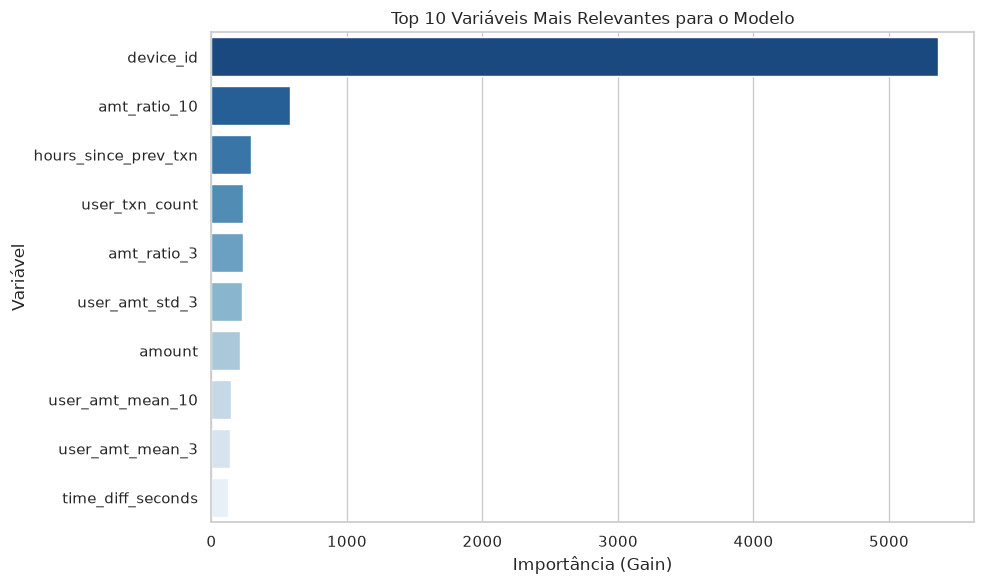

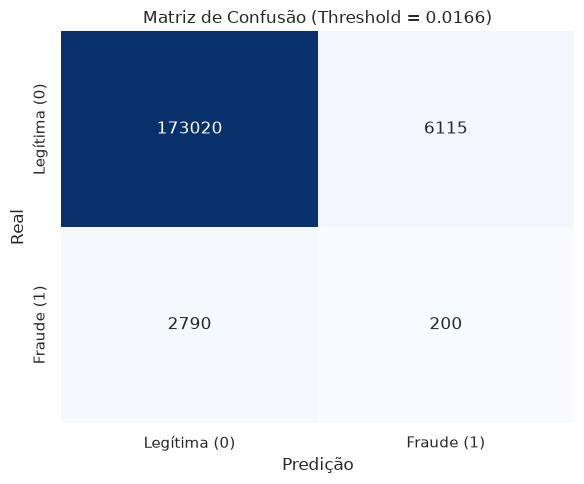


--- Métricas no Threshold Ótimo ---
              precision    recall  f1-score   support

Legítima (0)     0.9841    0.9659    0.9749    179135
  Fraude (1)     0.0317    0.0669    0.0430      2990

    accuracy                         0.9511    182125
   macro avg     0.5079    0.5164    0.5089    182125
weighted avg     0.9685    0.9511    0.9596    182125



In [44]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

# Cria diretório para armazenar as imagens do relatório
os.makedirs('../reports/figures', exist_ok=True)

# 1. Feature Importance do LightGBM
feature_imp = pd.DataFrame({
    'feature': features,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp.head(10), x='importance', y='feature', palette='Blues_r')
plt.title('Top 10 Variáveis Mais Relevantes para o Modelo')
plt.xlabel('Importância (Gain)')
plt.ylabel('Variável')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=300)
plt.show()

# 2. Curva Precision-Recall e Limiar Ótimo
precisions, recalls, thresholds = precision_recall_curve(y, oof_preds)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

# 3. Matriz de Confusão
oof_binary = (oof_preds >= best_threshold).astype(int)
cm = confusion_matrix(y, oof_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legítima (0)', 'Fraude (1)'],
            yticklabels=['Legítima (0)', 'Fraude (1)'])
plt.title(f'Matriz de Confusão (Threshold = {best_threshold:.4f})')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', dpi=300)
plt.show()

print("\n--- Métricas no Threshold Ótimo ---")
print(classification_report(y, oof_binary, target_names=['Legítima (0)', 'Fraude (1)'], digits=4))